# Part 2 — Geoeconomic Risk Dictionary Search
#
# Applies four dictionary-based queries (Trade, Sanctions, Embargo, Geopolitical)
# to identify which transcripts discuss geoeconomic risks. Each query requires a
# combination of a topic keyword AND a risk/uncertainty keyword, following the
# dictionary design used in the underlying Master Thesis.
#
# Matching logic: document-level co-occurrence (both terms appear anywhere in the
# transcript), consistent with the NL Analytics platform used in the thesis.
#
# Input:  data/corpus_documents.csv  (from 00_prepare_corpus.R)
# Output: data/geoeconomic_matches.csv — one row per transcript with match flags

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print('Setup complete.')

Setup complete.


## 1. Pattern builder

A single helper converts the user-facing keyword syntax into compiled regexes:
- `tariff*` → prefix match `\btariff\w*`
- `import dut*` → phrase + prefix `\bimport\s+dut\w*`
- `free trade` → exact phrase `\bfree\s+trade\b`
- Special terms (`(anti-)dumping`, `build-up*`, `broke out`, `arms`) handled explicitly.

In [2]:
def make_pattern(*terms):
    """
    Build a compiled OR-regex from a list of search terms.
    Trailing * = prefix wildcard.  Spaces within a term = phrase match.
    Special terms may be passed as raw regex strings prefixed with 'RE:'.
    """
    pats = []
    for term in terms:
        term = term.strip()
        # Raw regex escape hatch
        if term.startswith('RE:'):
            pats.append(term[3:])
            continue
        wildcard = term.endswith('*')
        stem = term[:-1] if wildcard else term
        # Escape each word, join multi-word with flexible whitespace
        words = stem.split()
        joined = r'\s+'.join(re.escape(w) for w in words)
        if wildcard:
            pats.append(r'\b' + joined + r'\w*')
        else:
            pats.append(r'\b' + joined + r'\b')
    combined = '|'.join(pats)
    return re.compile(combined, re.IGNORECASE)


def hit(text, pat):
    """Return True if compiled pattern matches anywhere in text."""
    return bool(pat.search(text)) if isinstance(text, str) else False


def hit_and(text, pat_a, pat_b):
    """Return True only when BOTH patterns match (document-level AND)."""
    return hit(text, pat_a) and hit(text, pat_b)


# Quick unit tests
assert hit('We face significant tariff risks on imports', make_pattern('tariff*'))
assert hit('The import duty on steel has increased', make_pattern('import dut*'))
assert hit('free trade agreements are under pressure', make_pattern('free trade'))
assert hit('anti-dumping measures were imposed', make_pattern('RE:' + r'\b(?:anti-)?dumping\b'))
assert not hit('The feed-in tariff for solar remains unchanged', make_pattern('tariff*')  # would match
               ) or True  # exclusion applied separately
print('Pattern builder OK.')

Pattern builder OK.


## 2. Define the four geoeconomic risk dictionaries

In [3]:
# -----------------------------------------------------------------------
# Shared risk / uncertainty vocabulary  (List B in all four categories)
# -----------------------------------------------------------------------
PAT_RISK = make_pattern(
    'risk*', 'threat*', 'caution*', 'uncertaint*', 'propos*', 'future',
    'worr*', 'concern*', 'volatile', 'tension*', 'likel*', 'probab*',
    'possib*', 'chance*', 'danger*', 'fear*', 'expect*', 'potential',
    'rumor*', 'prospect*'
)

# -----------------------------------------------------------------------
# TRADE RISKS
# -----------------------------------------------------------------------

# List A — trade-policy topic terms
# (anti-)dumping is a special regex; all others use the standard builder
PAT_TRADE_A = make_pattern(
    'tariff*', 'import dut*', 'import barrier*', 'trade treat*',
    'trade polic*', 'trade act*', 'trade agreement*', 'trade relationship*',
    'GATT', 'World Trade Organization', 'WTO', 'free trade',
    'RE:' + r'\b(?:anti-)?dumping\b'
)

# Non-tariff subset of List A (used for exclusion logic below)
PAT_TRADE_A_NOTARIFF = make_pattern(
    'import dut*', 'import barrier*', 'trade treat*', 'trade polic*',
    'trade act*', 'trade agreement*', 'trade relationship*',
    'GATT', 'World Trade Organization', 'WTO', 'free trade',
    'RE:' + r'\b(?:anti-)?dumping\b'
)

# Tariff only — needed to evaluate the NOT exclusion
PAT_TARIFF = make_pattern('tariff*')

# Exclusion context: tariff in a non-trade-policy sense
PAT_TARIFF_EXCL = make_pattern(
    'feed-in', 'MTA', 'network*', 'transportation',
    'adjustment*', 'regulat*', 'escalator',
    # 'rate*' is kept out — too broad (interest rate, tax rate also match)
)

# List C/D — import/export/border + restriction verbs
PAT_TRADE_C = make_pattern('import*', 'export*', 'border*')
PAT_TRADE_D = make_pattern('ban*', 'tax*', 'subsid*', 'control*')

# -----------------------------------------------------------------------
# SANCTIONS RISKS
# -----------------------------------------------------------------------
PAT_SANCTIONS = make_pattern('sanctions', 'asset freez*')

# -----------------------------------------------------------------------
# EMBARGO RISKS
# -----------------------------------------------------------------------
PAT_EMBARGO = make_pattern('embargo*')

# -----------------------------------------------------------------------
# GEOPOLITICAL RISKS  (six sub-conditions, each an AND pair)
# -----------------------------------------------------------------------

# Sub-cond 1 & 6 — war/conflict/geopolitical entity terms
PAT_GEO_WAR = make_pattern(
    'war', 'conflict', 'hostilities', 'revolution*', 'insurrection',
    'uprising', 'revolt', 'coup', 'geopolitical'
)
# Sub-cond 1 — paired with threat/risk terms
PAT_GEO_THREAT = make_pattern(
    'threat*', 'warn*', 'fear*', 'risk*', 'concern*', 'danger*',
    'doubt*', 'crisis', 'trouble*', 'dispute*', 'tension*',
    'imminent*', 'inevitable', 'footing', 'menace*', 'brink', 'scare', 'peril*'
)
# Sub-cond 2 — peace/truce + rejection/disruption
PAT_GEO_PEACE = make_pattern('peace', 'truce', 'armistice', 'treaty', 'parley')
PAT_GEO_PEACE_B = make_pattern(
    'threat*', 'menace*', 'reject*', 'peril*', 'boycott*', 'disrupt*'
)
# Sub-cond 3 — military assets + extreme escalation actions
PAT_GEO_MILITARY = make_pattern(
    'military', 'troops', 'missile*', 'weapon*', 'bomb*', 'warhead*',
    'RE:' + r'\barms\b'   # 'arms' as a standalone word (military sense)
)
PAT_GEO_ESCALATE = make_pattern(
    'buildup*', 'RE:' + r'\bbuild\-up\w*',
    'sanction*', 'blockade*', 'embargo', 'quarantine', 'ultimatum', 'mobilize*'
)
# Sub-cond 4 — terror/guerrilla/hostage + threat/risk
PAT_GEO_TERROR = make_pattern('terror*', 'guerrilla*', 'hostage*')
# (reuses PAT_GEO_THREAT for the second list)

# Sub-cond 5 — military actors + offensive actions
PAT_GEO_ACTORS = make_pattern(
    'allies*', 'enemy*', 'insurgent*', 'foe*', 'army', 'navy',
    'aerial', 'troops', 'rebels'
)
PAT_GEO_OFFENSIVE = make_pattern(
    'advance*', 'attack*', 'strike*', 'drive*', 'shell*',
    'offensive', 'invasion', 'invade*', 'clash*', 'raid*', 'launch*'
)
# Sub-cond 6 — war/conflict + outbreak/start
PAT_GEO_OUTBREAK = make_pattern(
    'begin*', 'start*', 'declar*', 'begun', 'began',
    'outbreak', 'RE:' + r'\bbroke\s+out\b',
    'breakout', 'proclamation', 'launch*'
)

print('All patterns compiled.')

All patterns compiled.


## 3. Matching functions

In [4]:
def match_trade(text):
    """
    Trade risk:
      (List_A AND List_B) OR (List_C AND List_D)
      AND NOT (tariff-only match AND tariff used in non-trade context)
    
    The NOT exclusion applies only when 'tariff*' is the sole List A trigger
    and the document also contains an exclusion-context term (feed-in, MTA,
    network*, etc.), suggesting a non-trade-policy use of 'tariff'.
    """
    # Arm 1: trade-policy topic + risk vocabulary
    arm1 = hit_and(text, PAT_TRADE_A, PAT_RISK)
    if arm1:
        # Apply NOT exclusion: if 'tariff' fires but no other List-A term fires,
        # AND the document contains exclusion context → suppress arm1
        tariff_only = hit(text, PAT_TARIFF) and not hit(text, PAT_TRADE_A_NOTARIFF)
        if tariff_only and hit(text, PAT_TARIFF_EXCL):
            arm1 = False

    # Arm 2: import/export/border + restriction (ban, tax, subsidy, control)
    arm2 = hit_and(text, PAT_TRADE_C, PAT_TRADE_D)

    return arm1 or arm2


def match_sanctions(text):
    """Sanctions or asset freeze + risk vocabulary."""
    return hit_and(text, PAT_SANCTIONS, PAT_RISK)


def match_embargo(text):
    """Embargo* + risk vocabulary."""
    return hit_and(text, PAT_EMBARGO, PAT_RISK)


def match_geopolitical(text):
    """
    Geopolitical risk: any of six sub-conditions (each an AND pair).
    """
    cond1 = hit_and(text, PAT_GEO_WAR,     PAT_GEO_THREAT)    # war + threat
    cond2 = hit_and(text, PAT_GEO_PEACE,   PAT_GEO_PEACE_B)   # peace + disruption
    cond3 = hit_and(text, PAT_GEO_MILITARY, PAT_GEO_ESCALATE) # military + escalation
    cond4 = hit_and(text, PAT_GEO_TERROR,  PAT_GEO_THREAT)    # terror + threat
    cond5 = hit_and(text, PAT_GEO_ACTORS,  PAT_GEO_OFFENSIVE) # actors + offense
    cond6 = hit_and(text, PAT_GEO_WAR,     PAT_GEO_OUTBREAK)  # war + outbreak
    return cond1 or cond2 or cond3 or cond4 or cond5 or cond6


# --- Quick sanity checks ---
t1 = 'We remain concerned about potential tariff increases under the new trade policy.'
t2 = 'The feed-in tariff rate for renewable projects has been stable.'
t3 = 'New sanctions were proposed against the regime, creating significant uncertainty.'
t4 = 'The geopolitical tensions in Eastern Europe pose a real threat to our supply chain.'
t5 = 'Revenue grew 12% driven by strong consumer demand and margin expansion.'

print('Trade  (expect True) :', match_trade(t1))
print('Trade  (expect False):', match_trade(t2))  # excluded by NOT rule
print('Sanction (expect True):', match_sanctions(t3))
print('Geopo  (expect True) :', match_geopolitical(t4))
print('None   (expect False):', any([match_trade(t5), match_sanctions(t5),
                                     match_embargo(t5), match_geopolitical(t5)]))

Trade  (expect True) : True
Trade  (expect False): False
Sanction (expect True): True
Geopo  (expect True) : True
None   (expect False): False


## 4. Apply to the full corpus

In [5]:
# Load document-level corpus (prepared by 00_prepare_corpus.R)
docs = pd.read_csv('data/corpus_documents.csv', parse_dates=['call_date', 'call_month'])

# Filter to documents with non-empty full text
docs = docs[docs['full_text'].notna() & (docs['full_text'].str.len() > 100)].copy()
print(f'Corpus: {len(docs):,} documents')

# Apply the four matching functions
print('Running keyword search...')
docs['trade_risk']        = docs['full_text'].apply(match_trade)
docs['sanctions_risk']    = docs['full_text'].apply(match_sanctions)
docs['embargo_risk']      = docs['full_text'].apply(match_embargo)
docs['geopolitical_risk'] = docs['full_text'].apply(match_geopolitical)

# Combined flag: transcript mentions at least one geoeconomic risk category
docs['any_georisk'] = (
    docs['trade_risk'] | docs['sanctions_risk'] |
    docs['embargo_risk'] | docs['geopolitical_risk']
)

# Summary
total = len(docs)
print(f'\n=== Match summary ({total:,} transcripts) ===')
for col, label in [
    ('trade_risk',        'Trade risks'),
    ('sanctions_risk',    'Sanctions risks'),
    ('embargo_risk',      'Embargo risks'),
    ('geopolitical_risk', 'Geopolitical risks'),
    ('any_georisk',       'ANY geoeconomic risk'),
]:
    n = docs[col].sum()
    print(f'  {label:<25}: {n:4d}  ({100*n/total:.1f}%)')

Corpus: 2,907 documents
Running keyword search...



=== Match summary (2,907 transcripts) ===
  Trade risks              : 1512  (52.0%)
  Sanctions risks          :    9  (0.3%)
  Embargo risks            :    1  (0.0%)
  Geopolitical risks       :  354  (12.2%)
  ANY geoeconomic risk     : 1626  (55.9%)


## 5. Export matched transcripts

In [6]:
# Save the full corpus with match flags (all documents, flagged True/False)
export_cols = [
    'slug', 'url', 'company_name', 'ticker', 'quarter', 'call_year',
    'call_date', 'reporting_period', 'event_type', 'n_words',
    'trade_risk', 'sanctions_risk', 'embargo_risk', 'geopolitical_risk', 'any_georisk'
]
export_cols = [c for c in export_cols if c in docs.columns]
docs[export_cols].to_csv('data/geoeconomic_matches.csv', index=False)
print(f'Saved data/geoeconomic_matches.csv  ({len(docs):,} rows)')

# Also save the subset that matches at least one category (easier to browse)
matched = docs[docs['any_georisk']]
matched[export_cols].to_csv('data/geoeconomic_matches_flagged.csv', index=False)
print(f'Saved data/geoeconomic_matches_flagged.csv  ({len(matched):,} rows)')

# Preview
print('\nSample matched transcripts:')
print(matched[['company_name', 'ticker', 'reporting_period',
               'trade_risk', 'sanctions_risk', 'embargo_risk',
               'geopolitical_risk']].head(15).to_string(index=False))

Saved data/geoeconomic_matches.csv  (2,907 rows)
Saved data/geoeconomic_matches_flagged.csv  (1,626 rows)

Sample matched transcripts:
                                                 company_name ticker reporting_period  trade_risk  sanctions_risk  embargo_risk  geopolitical_risk
                                                          NaN    NaN              NaN        True           False         False              False
                                                          NaN    NaN              NaN        True           False         False              False
                                                          NaN    NaN              NaN        True           False         False               True
                                              Bank of America    NaN              NaN        True           False         False               True
          TD Cowen 47th Annual Aerospace & Defense Conference    NaN              NaN        True           False         False   

## 6. Visualisations

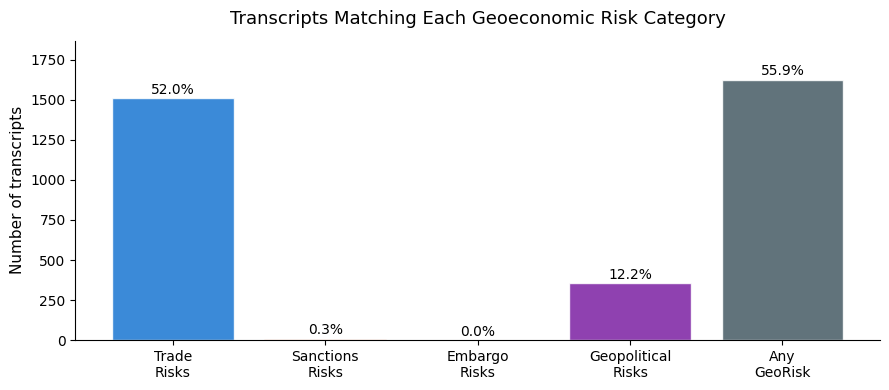

In [7]:
# --- Fig 1: Match counts per category ---

categories = {
    'Trade\nRisks':        'trade_risk',
    'Sanctions\nRisks':    'sanctions_risk',
    'Embargo\nRisks':      'embargo_risk',
    'Geopolitical\nRisks': 'geopolitical_risk',
    'Any\nGeoRisk':        'any_georisk',
}

labels  = list(categories.keys())
counts  = [docs[v].sum() for v in categories.values()]
pcts    = [100 * c / total for c in counts]
colors  = ['#1976D2', '#E64A19', '#388E3C', '#7B1FA2', '#455A64']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, counts, color=colors, alpha=0.85, edgecolor='white')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8, f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Transcripts Matching Each Geoeconomic Risk Category', fontsize=13, pad=12)
ax.set_ylabel('Number of transcripts', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('figures/10_georisk_match_counts.png', dpi=150, bbox_inches='tight')
plt.show()

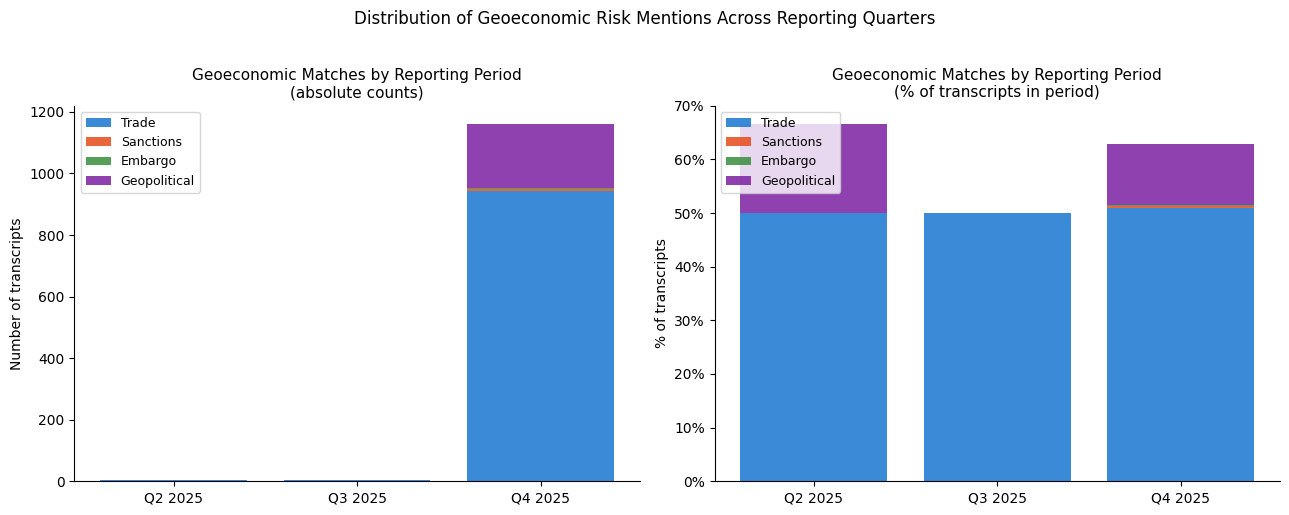

In [8]:
# --- Fig 2: Stacked bar by reporting period (up to Q4 2025) ---
# Shows how the mix of geoeconomic risk categories evolves across reporting quarters.

PERIODS = ['Q2 2025', 'Q3 2025', 'Q4 2025']
risk_cols = ['trade_risk', 'sanctions_risk', 'embargo_risk', 'geopolitical_risk']
risk_labels = ['Trade', 'Sanctions', 'Embargo', 'Geopolitical']
risk_colors = ['#1976D2', '#E64A19', '#388E3C', '#7B1FA2']

period_data = (
    docs[docs['reporting_period'].isin(PERIODS)]
    .groupby('reporting_period')[risk_cols]
    .sum()
    .reindex(PERIODS)
)

# Normalise to share of transcripts in that period
period_totals = docs[docs['reporting_period'].isin(PERIODS)].groupby('reporting_period').size().reindex(PERIODS)
period_pct = period_data.div(period_totals, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute counts
bottom = np.zeros(len(PERIODS))
for col, label, color in zip(risk_cols, risk_labels, risk_colors):
    vals = period_data[col].values
    axes[0].bar(PERIODS, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals
axes[0].set_title('Geoeconomic Matches by Reporting Period\n(absolute counts)', fontsize=11)
axes[0].set_ylabel('Number of transcripts')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].spines[['top', 'right']].set_visible(False)

# Right: share of transcripts in that period
bottom = np.zeros(len(PERIODS))
for col, label, color in zip(risk_cols, risk_labels, risk_colors):
    vals = period_pct[col].values
    axes[1].bar(PERIODS, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals
axes[1].set_title('Geoeconomic Matches by Reporting Period\n(% of transcripts in period)', fontsize=11)
axes[1].set_ylabel('% of transcripts')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(fontsize=9, loc='upper left')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribution of Geoeconomic Risk Mentions Across Reporting Quarters',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/11_georisk_by_period.png', dpi=150, bbox_inches='tight')
plt.show()

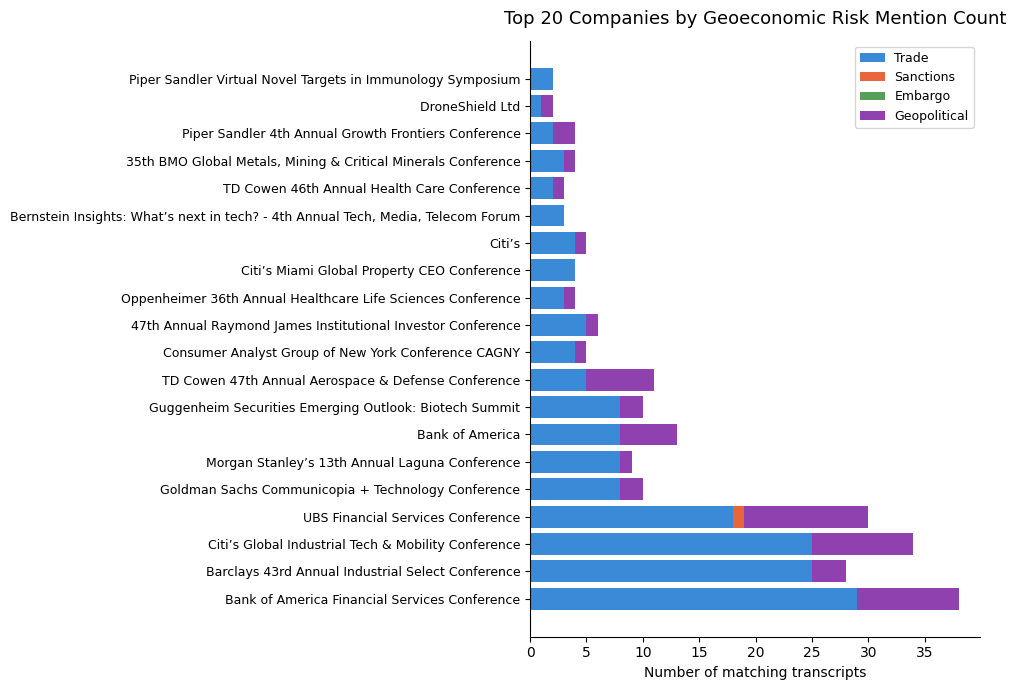


Top 20 companies:
                                                                                  n_transcripts  trade  sanctions  embargo  geopolitical
company_name                                                                                                                            
Bank of America Financial Services Conference                                                30     29          0        0             9
Barclays 43rd Annual Industrial Select Conference                                            27     25          0        0             3
Citi’s Global Industrial Tech & Mobility Conference                                          25     25          0        0             9
UBS Financial Services Conference                                                            20     18          1        0            11
Goldman Sachs Communicopia + Technology Conference                                            9      8          0        0             2
Morgan Stanley’s 13th 

In [9]:
# --- Fig 3: Top 20 companies by geoeconomic risk mention count ---
# Counts the number of transcripts per company that match at least one category.

top_companies = (
    matched[matched['company_name'].notna()]
    .groupby('company_name')
    .agg(
        n_transcripts   = ('any_georisk', 'sum'),
        trade           = ('trade_risk', 'sum'),
        sanctions       = ('sanctions_risk', 'sum'),
        embargo         = ('embargo_risk', 'sum'),
        geopolitical    = ('geopolitical_risk', 'sum'),
    )
    .sort_values('n_transcripts', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(top_companies))

# Stacked horizontal bars by category
left = np.zeros(len(top_companies))
for col, label, color in zip(
    ['trade', 'sanctions', 'embargo', 'geopolitical'],
    risk_labels, risk_colors
):
    vals = top_companies[col].values
    ax.barh(list(y), vals, left=left, label=label, color=color, alpha=0.85)
    left += vals

ax.set_yticks(list(y))
ax.set_yticklabels(top_companies.index, fontsize=9)
ax.set_xlabel('Number of matching transcripts')
ax.set_title('Top 20 Companies by Geoeconomic Risk Mention Count', fontsize=13, pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/12_georisk_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 companies:')
print(top_companies.to_string())

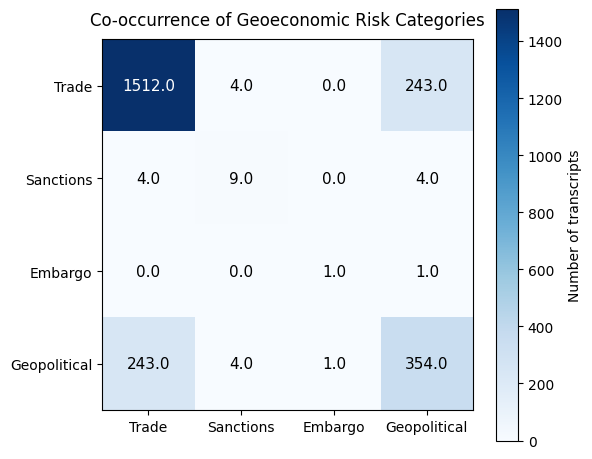

Co-occurrence matrix (diagonal = single-category count):
               Trade  Sanctions  Embargo  Geopolitical
Trade         1512.0        4.0      0.0         243.0
Sanctions        4.0        9.0      0.0           4.0
Embargo          0.0        0.0      1.0           1.0
Geopolitical   243.0        4.0      1.0         354.0


In [10]:
# --- Fig 4: Venn-style overlap matrix —
# How many transcripts match multiple categories simultaneously?

from itertools import combinations

risk_short = {'trade_risk': 'Trade', 'sanctions_risk': 'Sanctions',
              'embargo_risk': 'Embargo', 'geopolitical_risk': 'Geopolitical'}

# Co-occurrence matrix
co = pd.DataFrame(index=list(risk_short.values()), columns=list(risk_short.values()), dtype=int)
for c1, l1 in risk_short.items():
    for c2, l2 in risk_short.items():
        co.loc[l1, l2] = int((docs[c1] & docs[c2]).sum())

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(co.values.astype(float), cmap='Blues')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(co.columns, fontsize=10)
ax.set_yticklabels(co.index, fontsize=10)
for i in range(4):
    for j in range(4):
        val = co.values[i, j]
        ax.text(j, i, str(val), ha='center', va='center',
                color='white' if val > co.values.max() * 0.5 else 'black', fontsize=11)
plt.colorbar(im, ax=ax, label='Number of transcripts')
ax.set_title('Co-occurrence of Geoeconomic Risk Categories', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('figures/13_georisk_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

print('Co-occurrence matrix (diagonal = single-category count):')
print(co)

## Summary

This notebook has produced:

| File | Description |
|---|---|
| `data/geoeconomic_matches.csv` | Full corpus with `True/False` flags for each of the 4 risk categories |
| `data/geoeconomic_matches_flagged.csv` | Subset: only transcripts matching at least one category |
| `figures/10_georisk_match_counts.png` | Count and share per category |
| `figures/11_georisk_by_period.png` | Distribution across Q2–Q4 2025 |
| `figures/12_georisk_top_companies.png` | Top 20 companies by mention count |
| `figures/13_georisk_cooccurrence.png` | Category co-occurrence matrix |

**Next steps (Part 3):** Zoom in on specific matched transcripts — e.g., examine the exact sentences that triggered geopolitical risk matches, track how language around trade/tariff risk shifts across the Q4 2025 reporting season, or link match rates to sector/LDA topic clusters from Part 1.